In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
import glob

In [3]:
pred_files = [
    '/projects/retprogression/rgarridogarcia/rerun_5k_best_models/cropped1024_cropped_centered_wt_allR_1/predictions_best_balanced_acc_model.csv',
    '/projects/retprogression/rgarridogarcia/rerun_5k_best_models/cropped1024_cropped_centered_wt_allR_2/predictions_best_balanced_acc_model.csv',
    '/projects/retprogression/rgarridogarcia/rerun_5k_best_models/cropped1024_cropped_centered_wt_allR_3/predictions_best_balanced_acc_model.csv',
    '/projects/retprogression/rgarridogarcia/rerun_5k_best_models/cropped1024_cropped_centered_wt_allR_4/predictions_best_balanced_acc_model.csv',
    '/projects/retprogression/rgarridogarcia/rerun_5k_best_models/cropped1024_cropped_centered_wt_allR_5/predictions_best_balanced_acc_model.csv'
]

# Output directory
output_dir = '/projects/retprogression/rgarridogarcia/test_split_rerun5k'

# Split ratio (0.5 = 50/50 split)
calibration_ratio = 0.5

# Random seed for reproducibility
random_seed = 42

# Create output directory
os.makedirs(output_dir, exist_ok=True)

print(f"Found {len(pred_files)} prediction files:")
for i, f in enumerate(pred_files, 1):
    print(f"  {i}. {os.path.basename(f)}")

Found 5 prediction files:
  1. predictions_best_balanced_acc_model.csv
  2. predictions_best_balanced_acc_model.csv
  3. predictions_best_balanced_acc_model.csv
  4. predictions_best_balanced_acc_model.csv
  5. predictions_best_balanced_acc_model.csv


In [4]:
# Load first file
df_first = pd.read_csv(pred_files[0])

print(f"First file has {len(df_first)} samples")
print(f"Columns: {list(df_first.columns)}")
print(f"\nFirst 5 rows:")
df_first.head()

First file has 1651 samples
Columns: ['image_id', 'original_index', 'true_label', 'predicted_label', 'prob_class_0', 'prob_class_1', 'logit_0', 'logit_1', 'logit_margin', 'correct']

First 5 rows:


,image_id,original_index,true_label,predicted_label,prob_class_0,prob_class_1,logit_0,logit_1,logit_margin,correct
0,605221,0,1,1,0.014081,0.985919,-3.014064,1.234665,4.248729,True
1,605222,1,1,1,0.012060,0.987940,-2.897580,1.508149,4.405729,True
2,605367,2,0,1,0.009193,0.990807,-3.015798,1.664281,4.680079,False
3,605368,3,0,1,0.012722,0.987278,-2.791726,1.559910,4.351636,False
4,605394,4,1,1,0.004319,0.995681,-3.074159,2.366153,5.440312,True


In [5]:
# Auto-detect ID column
id_col = None
for possible_id in ['image_id', 'id', 'ID', 'image_filename']:
    if possible_id in df_first.columns:
        id_col = possible_id
        break

# Auto-detect label column
true_col = None
for possible_label in ['true_label', 'y_true', 'label']:
    if possible_label in df_first.columns:
        true_col = possible_label
        break

print(f"Detected columns:")
print(f"  ID column: {id_col}")
print(f"  Label column: {true_col}")

if not id_col or not true_col:
    print("\n⚠️ Could not auto-detect columns. Please set manually:")
    print("  id_col = 'your_id_column_name'")
    print("  true_col = 'your_label_column_name'")

Detected columns:
  ID column: image_id
  Label column: true_label


In [6]:
# Get unique samples (in case same sample appears in multiple files)
sample_info = df_first[[id_col, true_col]].drop_duplicates()

print(f"Total unique samples: {len(sample_info)}")
print(f"\nClass distribution:")
print(sample_info[true_col].value_counts())
print(f"\nClass percentages:")
print(sample_info[true_col].value_counts(normalize=True) * 100)

Total unique samples: 1651

Class distribution:
true_label
1    1612
0      39
Name: count, dtype: int64

Class percentages:
true_label
1    97.637795
0     2.362205
Name: proportion, dtype: float64


In [7]:
# Get sample IDs and labels
sample_ids = sample_info[id_col].values
labels = sample_info[true_col].values

# Stratified split
cal_ids, val_ids = train_test_split(
    sample_ids,
    test_size=(1 - calibration_ratio),
    stratify=labels,
    random_state=random_seed
)

print(f"Split summary:")
print(f"  Calibration: {len(cal_ids)} samples ({100*len(cal_ids)/len(sample_ids):.1f}%)")
print(f"  Validation:  {len(val_ids)} samples ({100*len(val_ids)/len(sample_ids):.1f}%)")

# Verify class balance in splits
cal_labels = sample_info[sample_info[id_col].isin(cal_ids)][true_col]
val_labels = sample_info[sample_info[id_col].isin(val_ids)][true_col]

print(f"\nCalibration set class distribution:")
print(cal_labels.value_counts())
print(f"Percentages: {cal_labels.value_counts(normalize=True) * 100}")

print(f"\nValidation set class distribution:")
print(val_labels.value_counts())
print(f"Percentages: {val_labels.value_counts(normalize=True) * 100}")

Split summary:
  Calibration: 825 samples (50.0%)
  Validation:  826 samples (50.0%)

Calibration set class distribution:
true_label
1    806
0     19
Name: count, dtype: int64
Percentages: true_label
1    97.69697
0     2.30303
Name: proportion, dtype: float64

Validation set class distribution:
true_label
1    806
0     20
Name: count, dtype: int64
Percentages: true_label
1    97.578692
0     2.421308
Name: proportion, dtype: float64


In [8]:
print(output_dir)

/projects/retprogression/rgarridogarcia/test_split_rerun5k


In [9]:
# Save ID lists
cal_id_file = os.path.join(output_dir, 'calibration_sample_ids.csv')
val_id_file = os.path.join(output_dir, 'validation_sample_ids.csv')

pd.DataFrame({id_col: cal_ids}).to_csv(cal_id_file, index=False)
pd.DataFrame({id_col: val_ids}).to_csv(val_id_file, index=False)

print(f"✅ Saved calibration IDs: {cal_id_file}")
print(f"✅ Saved validation IDs: {val_id_file}")

✅ Saved calibration IDs: /projects/retprogression/rgarridogarcia/test_split_rerun5k/calibration_sample_ids.csv
✅ Saved validation IDs: /projects/retprogression/rgarridogarcia/test_split_rerun5k/validation_sample_ids.csv


In [10]:
# Convert to sets for fast lookup
cal_ids_set = set(cal_ids.astype(str))
val_ids_set = set(val_ids.astype(str))

cal_files = []
val_files = []

print("Filtering prediction files...\n")

for i, pred_file in enumerate(pred_files, 1):
    print(f"Processing: {os.path.basename(pred_file)} (from partition {i})")
    
    # Load predictions
    df = pd.read_csv(pred_file)
    
    # Detect ID column in this file
    file_id_col = None
    for possible_id in ['image_id', 'id', 'ID', 'image_filename']:
        if possible_id in df.columns:
            file_id_col = possible_id
            break
    
    if file_id_col is None:
        print(f"  ⚠️  No ID column found, skipping")
        continue
    
    # Filter for calibration
    df_cal = df[df[file_id_col].astype(str).isin(cal_ids_set)].copy()
    
    # Filter for validation
    df_val = df[df[file_id_col].astype(str).isin(val_ids_set)].copy()
    
    print(f"  Original: {len(df)} → Calibration: {len(df_cal)}, Validation: {len(df_val)}")
    
    # Save with partition number to avoid overwriting
    cal_file = os.path.join(output_dir, f'predictions_model_{i}_calibration.csv')
    val_file = os.path.join(output_dir, f'predictions_model_{i}_validation.csv')
    
    df_cal.to_csv(cal_file, index=False)
    df_val.to_csv(val_file, index=False)
    
    cal_files.append(cal_file)
    val_files.append(val_file)

print(f"\n✅ Created {len(cal_files)} calibration files")
print(f"✅ Created {len(val_files)} validation files")

Filtering prediction files...

Processing: predictions_best_balanced_acc_model.csv (from partition 1)
  Original: 1651 → Calibration: 825, Validation: 826
Processing: predictions_best_balanced_acc_model.csv (from partition 2)
  Original: 1651 → Calibration: 825, Validation: 826
Processing: predictions_best_balanced_acc_model.csv (from partition 3)
  Original: 1651 → Calibration: 825, Validation: 826
Processing: predictions_best_balanced_acc_model.csv (from partition 4)
  Original: 1651 → Calibration: 825, Validation: 826
Processing: predictions_best_balanced_acc_model.csv (from partition 5)
  Original: 1651 → Calibration: 825, Validation: 826

✅ Created 5 calibration files
✅ Created 5 validation files


In [11]:
# Save calibration file list
with open(os.path.join(output_dir, 'calibration_files.txt'), 'w') as f:
    for file in cal_files:
        f.write(file + '\n')

# Save validation file list
with open(os.path.join(output_dir, 'validation_files.txt'), 'w') as f:
    for file in val_files:
        f.write(file + '\n')

print("✅ Saved file lists")
print(f"\nCalibration files:")
for f in cal_files:
    print(f"  - {os.path.basename(f)}")

print(f"\nValidation files:")
for f in val_files:
    print(f"  - {os.path.basename(f)}")

✅ Saved file lists

Calibration files:
  - predictions_model_1_calibration.csv
  - predictions_model_2_calibration.csv
  - predictions_model_3_calibration.csv
  - predictions_model_4_calibration.csv
  - predictions_model_5_calibration.csv

Validation files:
  - predictions_model_1_validation.csv
  - predictions_model_2_validation.csv
  - predictions_model_3_validation.csv
  - predictions_model_4_validation.csv
  - predictions_model_5_validation.csv


In [12]:
# Check one calibration file
cal_sample = pd.read_csv(cal_files[0])
print(f"Sample calibration file: {os.path.basename(cal_files[0])}")
print(f"  Samples: {len(cal_sample)}")
print(f"  Columns: {list(cal_sample.columns)}")
print(f"\nClass distribution:")
print(cal_sample[true_col].value_counts())

# Check one validation file
val_sample = pd.read_csv(val_files[0])
print(f"\nSample validation file: {os.path.basename(val_files[0])}")
print(f"  Samples: {len(val_sample)}")
print(f"\nClass distribution:")
print(val_sample[true_col].value_counts())

# Verify no overlap
cal_ids_check = set(cal_sample[file_id_col].astype(str))
val_ids_check = set(val_sample[file_id_col].astype(str))
overlap = cal_ids_check & val_ids_check

if len(overlap) == 0:
    print(f"\n✅ No overlap between calibration and validation sets")
else:
    print(f"\n⚠️ WARNING: {len(overlap)} samples appear in both sets!")

Sample calibration file: predictions_model_1_calibration.csv
  Samples: 825
  Columns: ['image_id', 'original_index', 'true_label', 'predicted_label', 'prob_class_0', 'prob_class_1', 'logit_0', 'logit_1', 'logit_margin', 'correct']

Class distribution:
true_label
1    806
0     19
Name: count, dtype: int64

Sample validation file: predictions_model_1_validation.csv
  Samples: 826

Class distribution:
true_label
1    806
0     20
Name: count, dtype: int64

✅ No overlap between calibration and validation sets


In [13]:
print("="*80)
print("SPLIT COMPLETE!")
print("="*80)
print(f"\nOutput directory: {output_dir}")
print(f"\nFiles created:")
print(f"  - calibration_sample_ids.csv ({len(cal_ids)} IDs)")
print(f"  - validation_sample_ids.csv ({len(val_ids)} IDs)")
print(f"  - {len(cal_files)} calibration prediction files")
print(f"  - {len(val_files)} validation prediction files")
print(f"  - calibration_files.txt (list of calibration files)")
print(f"  - validation_files.txt (list of validation files)")

print(f"\n{'='*80}")
print("NEXT STEPS:")
print("="*80)

print(f"\n1. Create ensembles on CALIBRATION set and tune thresholds:")
print(f"\ncd /home/r.garridogarcia/MIGHTE/retprogression/swinV2/RETProgression/src")
print(f"\npython ensemble_cross_validation.py \\")
print(f"    --predictions \\")
for f in cal_files:
    print(f"        {f} \\")
print(f"    --output_dir /projects/retprogression/rgarridogarcia/ensemble/ensemble_calibration \\")
print(f"    --methods all \\")
print(f"    --conservative_voting \\")
print(f"    --tune_threshold")

print(f"\n2. Create ensembles on VALIDATION set (no tuning):")
print(f"\npython ensemble_cross_validation.py \\")
print(f"    --predictions \\")
for f in val_files:
    print(f"        {f} \\")
print(f"    --output_dir /projects/retprogression/rgarridogarcia/ensemble/ensemble_validation \\")
print(f"    --methods all \\")
print(f"    --conservative_voting")

print(f"\n3. Apply calibrated thresholds to validation set:")
print(f"\npython apply_calibrated_thresholds.py \\")
print(f"    --calibration_file /projects/.../ensemble_calibration/best_thresholds_summary.csv \\")
print(f"    --new_ensemble_dir /projects/.../ensemble_validation \\")
print(f"    --output_dir /projects/.../final_validation_results")

SPLIT COMPLETE!

Output directory: /projects/retprogression/rgarridogarcia/test_split_rerun5k

Files created:
  - calibration_sample_ids.csv (825 IDs)
  - validation_sample_ids.csv (826 IDs)
  - 5 calibration prediction files
  - 5 validation prediction files
  - calibration_files.txt (list of calibration files)
  - validation_files.txt (list of validation files)

NEXT STEPS:

1. Create ensembles on CALIBRATION set and tune thresholds:

cd /home/r.garridogarcia/MIGHTE/retprogression/swinV2/RETProgression/src

python ensemble_cross_validation.py \
    --predictions \
        /projects/retprogression/rgarridogarcia/test_split_rerun5k/predictions_model_1_calibration.csv \
        /projects/retprogression/rgarridogarcia/test_split_rerun5k/predictions_model_2_calibration.csv \
        /projects/retprogression/rgarridogarcia/test_split_rerun5k/predictions_model_3_calibration.csv \
        /projects/retprogression/rgarridogarcia/test_split_rerun5k/predictions_model_4_calibration.csv \
       

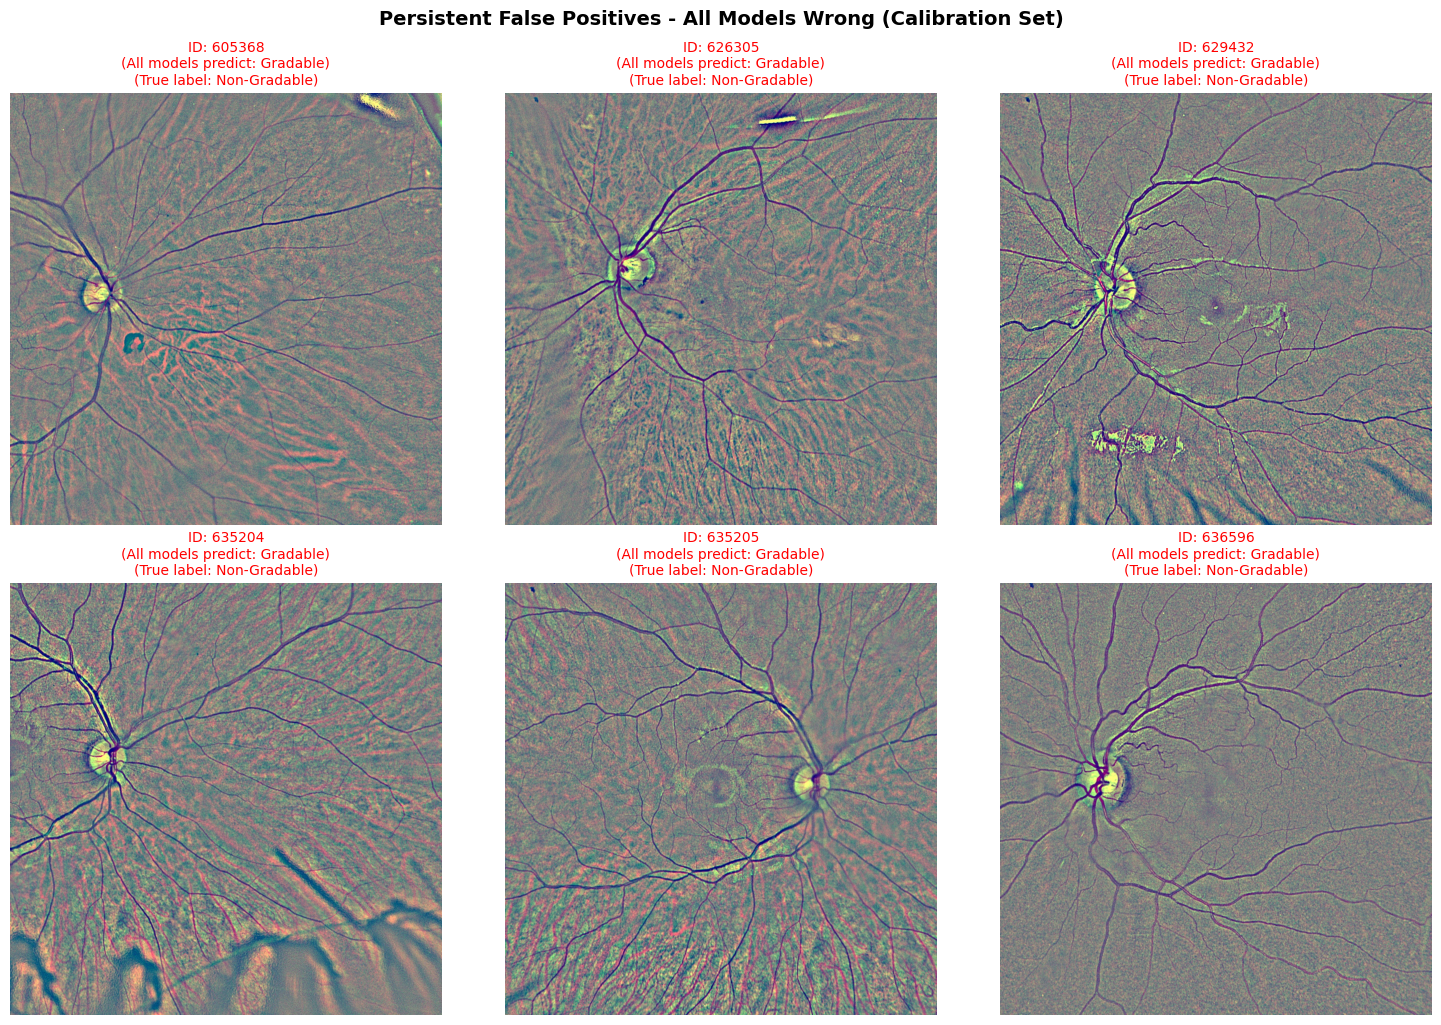


Image file paths:
  605368: /projects/retprogression/test_cropped1024_wt_10272025/605368.jpg
  626305: /projects/retprogression/test_cropped1024_wt_10272025/626305.jpg
  629432: /projects/retprogression/test_cropped1024_wt_10272025/629432.jpg
  635204: /projects/retprogression/test_cropped1024_wt_10272025/635204.jpg
  635205: /projects/retprogression/test_cropped1024_wt_10272025/635205.jpg
  636596: /projects/retprogression/test_cropped1024_wt_10272025/636596.jpg


In [25]:
# Display the 6 persistent false positive images
import matplotlib.pyplot as plt
from PIL import Image
import os

# The 6 sample IDs that are always misclassified
fp_sample_ids = ['605368', '626305', '629432', '635204', '635205', '636596']

# Path to your image directory
img_dir = '/projects/retprogression/test_cropped1024_wt_10272025'

# Create figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, sample_id in enumerate(fp_sample_ids):
    # Try different extensions
    img_path = None
    for ext in ['.jpg', '.png', '.jpeg', '.JPG', '.PNG']:
        test_path = os.path.join(img_dir, f'{sample_id}{ext}')
        if os.path.exists(test_path):
            img_path = test_path
            break
    
    if img_path and os.path.exists(img_path):
        # Load and display image
        img = Image.open(img_path)
        axes[i].imshow(img)
        axes[i].set_title(f'ID: {sample_id}\n(All models predict: Gradable)\n(True label: Non-Gradable)', 
                         fontsize=10, color='red')
        axes[i].axis('off')
    else:
        axes[i].text(0.5, 0.5, f'Image {sample_id}\nNot Found', 
                    ha='center', va='center', fontsize=12)
        axes[i].set_title(f'ID: {sample_id}')
        axes[i].axis('off')

plt.tight_layout()
plt.suptitle('Persistent False Positives - All Models Wrong (Calibration Set)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.show()

# Print file paths for manual inspection
print("\nImage file paths:")
for sample_id in fp_sample_ids:
    for ext in ['.jpg', '.png', '.jpeg']:
        test_path = os.path.join(img_dir, f'{sample_id}{ext}')
        if os.path.exists(test_path):
            print(f"  {sample_id}: {test_path}")
            break
    else:
        print(f"  {sample_id}: NOT FOUND")